<a href="https://colab.research.google.com/github/ciptomx/Clustering-cici/blob/main/FINAL_PREDIKSI_TINGGI_MUKA_AIR_SUNGAI_KAPUAS_MENGGUNAKAN_MODEL_PATCHTST_BERBASIS_TRANSFORMER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PREDIKSI TINGGI MUKA AIR SUNGAI KAPUAS MENGGUNAKAN MODEL PATCHTST BERBASIS TRANSFORMER**

#**INSTALL LIBRARY**

In [ ]:
!pip install neuralforecast pandas openpyxl matplotlib statsforecast

# **1. IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.numpy import mae, mse, rmse

# **2. UPLOAD FILE DATASET**

In [ ]:
print("\n[INFO] Silakan upload file dataset (DataAWSFinal.xlsx)...")

uploaded = files.upload()

file_path = 'DataAWSFinal.xlsx'


[INFO] Silakan upload file dataset (DataAWSFinal.xlsx)...


Saving DataAWSFinal.xlsx to DataAWSFinal (3).xlsx


# **3. PARAMETER MODEL & EVALUASI**

In [ ]:
# Window historis 14 hari
WINDOW_SIZE = 336

# Data testing 30 hari
TEST_SIZE = 720

# Horizon prediksi
HORIZON = TEST_SIZE

# Maksimal training steps
MAX_STEPS = 5000

# **4. LOAD & PREPROCESSING**

In [ ]:
print("\n[INFO] Memuat dan memproses data...")

try:
    df = pd.read_excel(file_path)

except:
    import os
    file_path = list(uploaded.keys())[0]
    df = pd.read_excel(file_path)

# Rename kolom sesuai NeuralForecast
df_nf = df.rename(columns={
    'waktu': 'ds',
    'waterlevel': 'y'
})

# Tambahkan unique_id
df_nf['unique_id'] = 'AWS_Station'

# Konversi datetime
df_nf['ds'] = pd.to_datetime(df_nf['ds'])

# Ambil kolom penting
df_nf = df_nf[
    ['unique_id', 'ds', 'y']
].sort_values('ds').reset_index(drop=True)


[INFO] Memuat dan memproses data...


# **5. SPLIT DATA TRAIN & TEST**

In [ ]:
train_size = len(df_nf) - TEST_SIZE

df_train = df_nf.iloc[:train_size].copy()
df_test  = df_nf.iloc[train_size:].copy()

# Interpolasi hanya pada train
df_train['y'] = (
    df_train['y']
    .interpolate(method='linear')
    .ffill()
    .bfill()
)

print(f"\nTotal Data : {len(df_nf)}")
print(f"Data Train : {len(df_train)}")
print(f"Data Test  : {len(df_test)}")


Total Data : 43080
Data Train : 42360
Data Test  : 720


# **6. MEMBANGUN MODEL PATCHTST**

In [ ]:
print("\n[INFO] Memulai Training Model PatchTST...")

models = [
    PatchTST(
        h=HORIZON,
        input_size=WINDOW_SIZE,

        # Maksimum training
        max_steps=MAX_STEPS,

        # Early stopping
        early_stop_patience_steps=5,

        # Batch size
        batch_size=32,

        # Transformer encoder
        encoder_layers=3,

        # Learning rate
        learning_rate=1e-3,

        # Normalisasi otomatis
        scaler_type='standard',

        # Hyperparameter PatchTST
        patch_len=24,
        stride=12
    )
]

# Framework NeuralForecast
nf = NeuralForecast(
    models=models,
    freq='h'
)

INFO:lightning_fabric.utilities.seed:Seed set to 1



[INFO] Memulai Training Model PatchTST...


# **7. TRAINING MODEL**

In [ ]:
nf.fit(
    df=df_train,
    val_size=HORIZON
)

print("\n[INFO] Training selesai.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 3.0 M  | train
-----------------------------------------------------------
3.0 M     Trainable params
3         Non-trainable params
3.0 M     Total params
11.942    Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


[INFO] Training selesai.


# **8. Prediksi**

In [ ]:
print("\n[INFO] Melakukan Prediksi...")

forecast_df = nf.predict(df=df_train)

forecast_df = forecast_df.reset_index()

# Gabungkan hasil prediksi dengan data aktual
result_df = pd.merge(
    df_test,
    forecast_df[['ds', 'PatchTST']],
    on='ds',
    how='inner'
)

# Hapus nilai kosong
result_df = result_df.dropna(subset=['y'])

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Melakukan Prediksi...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

# **9. EVALUASI MODEL**

In [ ]:
y_true = result_df['y'].values
y_pred = result_df['PatchTST'].values

mae_val = mae(y_true, y_pred)
mse_val = mse(y_true, y_pred)
rmse_val = rmse(y_true, y_pred)

print("\n" + "="*45)
print("     HASIL EVALUASI MODEL PATCHTST")
print("="*45)

print(f"MAE  : {mae_val:.5f}")
print(f"MSE  : {mse_val:.5f}")
print(f"RMSE : {rmse_val:.5f}")

print("="*45)


     HASIL EVALUASI MODEL PATCHTST
MAE  : 0.10332
MSE  : 0.02934
RMSE : 0.17127


# **10. VISUALISASI (1 MINGGU PERTAMA)**

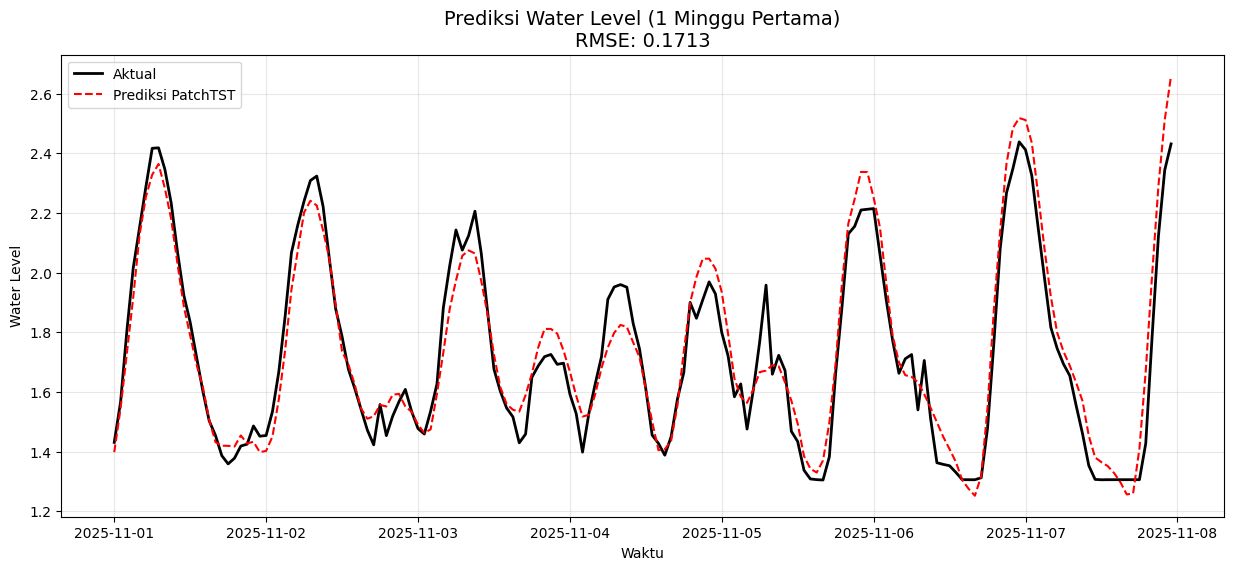

In [ ]:
plt.figure(figsize=(15,6))

plot_df = result_df.head(168)

plt.plot(
    plot_df['ds'],
    plot_df['y'],
    label='Aktual',
    color='black',
    linewidth=2
)

plt.plot(
    plot_df['ds'],
    plot_df['PatchTST'],
    label='Prediksi PatchTST',
    color='red',
    linestyle='--'
)

plt.title(
    f'Prediksi Water Level (1 Minggu Pertama)\nRMSE: {rmse_val:.4f}',
    fontsize=14
)

plt.xlabel('Waktu')
plt.ylabel('Water Level')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# **11. VISUALISASI FULL 720 JAM**

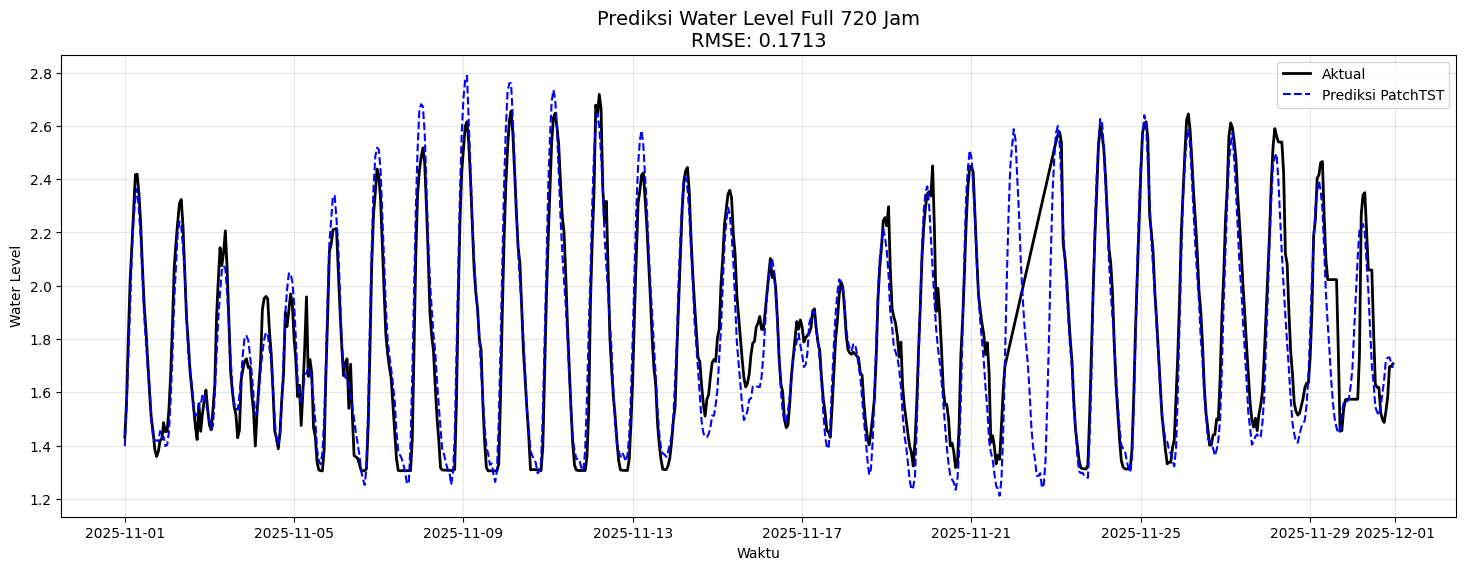

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(
    result_df['ds'],
    result_df['y'],
    label='Aktual',
    color='black',
    linewidth=2
)

plt.plot(
    result_df['ds'],
    result_df['PatchTST'],
    label='Prediksi PatchTST',
    color='blue',
    linestyle='--'
)

plt.title(
    f'Prediksi Water Level Full 720 Jam\nRMSE: {rmse_val:.4f}',
    fontsize=14
)

plt.xlabel('Waktu')
plt.ylabel('Water Level')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# **12. RESIDUAL ERROR PLOT**

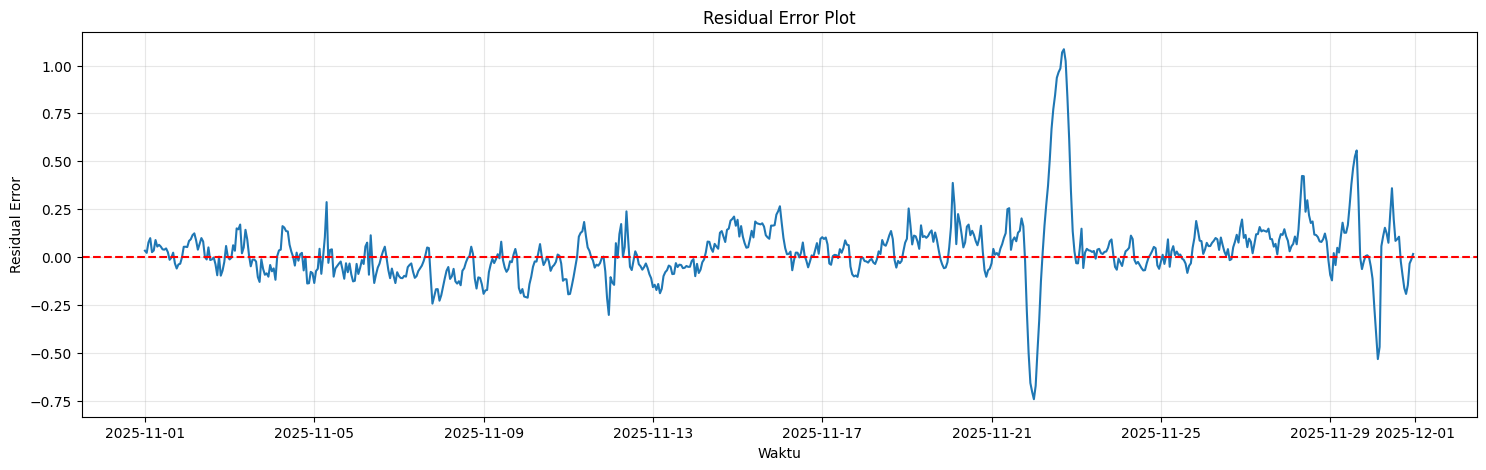

In [ ]:
# Residual = Aktual - Prediksi
result_df['Residual'] = (
    result_df['y'] - result_df['PatchTST']
)

plt.figure(figsize=(18,5))

plt.plot(
    result_df['ds'],
    result_df['Residual']
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title('Residual Error Plot')
plt.xlabel('Waktu')
plt.ylabel('Residual Error')

plt.grid(True, alpha=0.3)

plt.show()

# **13. DETAIL HASIL PREDIKSI**

In [ ]:
print("\nDetail 24 Jam Pertama Prediksi:\n")

print(
    result_df[
        ['ds', 'y', 'PatchTST', 'Residual']
    ].head(24)
)


Detail 24 Jam Pertama Prediksi:

                    ds         y  PatchTST  Residual
0  2025-11-01 00:00:00  1.430950  1.398276  0.032674
1  2025-11-01 01:00:00  1.566367  1.544985  0.021381
2  2025-11-01 02:00:00  1.805500  1.729693  0.075807
3  2025-11-01 03:00:00  2.015500  1.917229  0.098271
4  2025-11-01 04:00:00  2.150917  2.125856  0.025060
5  2025-11-01 05:00:00  2.287283  2.253633  0.033650
6  2025-11-01 06:00:00  2.416650  2.328220  0.088430
7  2025-11-01 07:00:00  2.418150  2.363910  0.054240
8  2025-11-01 08:00:00  2.346200  2.282766  0.063434
9  2025-11-01 09:00:00  2.232850  2.178890  0.053960
10 2025-11-01 10:00:00  2.068550  2.028764  0.039786
11 2025-11-01 11:00:00  1.924033  1.886112  0.037921
12 2025-11-01 12:00:00  1.833483  1.788924  0.044559
13 2025-11-01 13:00:00  1.717067  1.692185  0.024882
14 2025-11-01 14:00:00  1.602717  1.617465 -0.014749
15 2025-11-01 15:00:00  1.503533  1.507110 -0.003577
16 2025-11-01 16:00:00  1.454033  1.431630  0.022404
17 2025-11-0

In [ ]:
y_pred

array([1.3982763, 1.5449852, 1.7296928, 1.9172288, 2.1258564, 2.2536335,
       2.32822  , 2.3639097, 2.2827656, 2.1788902, 2.0287645, 1.8861119,
       1.7889241, 1.6921848, 1.6174653, 1.5071101, 1.4316298, 1.4200408,
       1.4193486, 1.4170272, 1.4542149, 1.4273837, 1.4330542, 1.3983867,
       1.4023252, 1.4506687, 1.5744374, 1.7386998, 1.943264 , 2.0721762,
       2.2017748, 2.2408504, 2.2249608, 2.141321 , 2.045142 , 1.8907095,
       1.7358584, 1.6922629, 1.6248168, 1.5448941, 1.5102416, 1.518439 ,
       1.5563442, 1.5513324, 1.5905322, 1.593615 , 1.5513783, 1.5331864,
       1.4901505, 1.462745 , 1.4746888, 1.5947269, 1.7322507, 1.8770542,
       1.9735719, 2.0563674, 2.0745165, 2.0640612, 1.9717712, 1.8589165,
       1.7256231, 1.6170906, 1.5596086, 1.5403174, 1.5342401, 1.5893251,
       1.6617002, 1.7494991, 1.8111818, 1.8112607, 1.795515 , 1.7384691,
       1.6679616, 1.5870786, 1.5175582, 1.5232618, 1.5923512, 1.6803205,
       1.7494525, 1.7982086, 1.8246058, 1.8178626, 